The entire folderm that comprises this file , is set to statistically answer the question that , can measurement correlation be confused with population level correlation. 
for this purpose , I will make a grid of values of $\rho$ and $\rho_2$ and then obtain an infered trace for $\rho$ and furthur analyse 

The mathematics that the entire functions below uses is given above 

In [1]:
import numpy as np 
import scipy.stats as st
import pymc as pm
import matplotlib.pyplot as plt 
import arviz as az 
import pickle 
import pytensor.tensor as pt
import corner

In [2]:
Nobs=10000

In [ ]:
np.random.seed(123)
def plotter2(x_obs,y_obs,x_name,y_name):
    fig = plt.figure(figsize=(8, 8))
    grid = plt.GridSpec(4, 4, hspace=0.4, wspace=0.4)
    main_ax = fig.add_subplot(grid[1:4, 0:3])
    main_ax.scatter(x_obs, y_obs, alpha=0.6, color='darkorange', s=25)
    main_ax.set_title("Scatter Plot of "+x_name+" vs "+ y_name , fontsize=14)
    main_ax.set_xlabel(x_name, fontsize=12)
    main_ax.set_ylabel(y_name, fontsize=12)
    main_ax.grid(True, linestyle='--', alpha=0.6)

    x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)
    x_hist.hist(x_obs, bins=30, color='gold', edgecolor='k')
    x_hist.set_title("Histogram of "+x_name, fontsize=12)
    x_hist.grid(True, linestyle='--', alpha=0.5)

    y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)
    y_hist.hist(y_obs, bins=30, orientation='horizontal', color='tomato', edgecolor='k')
    y_hist.set_title("Histogram of  "+y_name, fontsize=12)
    y_hist.grid(True, linestyle='--', alpha=0.5)

    plt.show()
def plotter1(x,x_name):
    plt.hist(x,bins=50,color='blue')
    plt.title("Histogram of "+x_name)
    plt.xlabel(x_name)
    plt.ylabel("Pm("+x_name+")")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

The function below , is an automated posterior inference generator, the function takes the true population and measurement correlation of for the distribution as paraters and the rest population parameters are set to some arbritary values that are contained within the boundaries of the priors used, the mathematics of this follows the previous notebooks in this repo. 
$$\\$$
The trace/posterior generated is stored in pkl file format, for the inference.ipynb to access.

In [ ]:
def tracemaker(p_t,p2_t):
    #just formatting the output to look clean, following three statements serve no other purpose
    for i in range(10): print() 
    print("Obtaining inference for p=",p_t,"and p2=",p2_t,sep="") 
    for i in range(10): print()
    mu_t_x=1
    mu_t_y=1
    sigma_t_y=2
    sigma_t_x=2
    sigma_obs_x=3
    sigma_obs_y=2
    cov = [
          [sigma_t_x**2, p_t * sigma_t_x * sigma_t_y],
        [p_t * sigma_t_x * sigma_t_y, sigma_t_y**2]
    ]   
    mean = [mu_t_x, mu_t_y]
    x, y = np.random.multivariate_normal(mean, cov, Nobs).T
    plotter2(x,y,"x","y")
    #observed variables
    x_obs = np.zeros(Nobs)
    y_obs = np.zeros(Nobs) 
    for i in range(Nobs):
        cov = [
            [sigma_obs_x**2, p2_t * sigma_obs_x * sigma_obs_y],
            [p2_t * sigma_obs_x * sigma_obs_y, sigma_obs_y**2]
        ]
        mean = [x[i], y[i]]
        x_obs[i], y_obs[i] = np.random.multivariate_normal(mean, cov)
    plotter2(x_obs,y_obs,r"$x_{obs}$",r"$y_{obs}$")
    data = np.column_stack((x_obs, y_obs))
    with pm.Model() as model:
        # Priors
        mu_x = pm.Uniform("mu_x", -4, 4)
        mu_y = pm.Uniform("mu_y", -4, 4)
        sigma_x = pm.Uniform("sigma_x", 0, 3)
        sigma_y = pm.Uniform("sigma_y", 0, 3)
        p = pm.Uniform("p", -1, 1)
        sx = pt.sqrt(sigma_obs_x**2 + sigma_x**2)
        sy = pt.sqrt(sigma_obs_y**2 + sigma_y**2)
        p2=p2_t
        # Mean vector
        mu_vec = pt.stack([mu_x, mu_y])
        cov = pt.stacklists([
            [sx**2, p * sigma_x * sigma_y+p2*sigma_obs_x*sigma_obs_y],
            [p * sigma_x * sigma_y+sigma_obs_y*p2*sigma_obs_x, sy**2]
        ])
        obs = pm.MvNormal("obs", mu=mu_vec, cov=cov, observed=data)
        # Sampling
        trace = pm.sample(draws=4000, tune=4000, chains=4,cores=4, target_accept=0.95)
            
    axes=az.plot_trace(            
            trace,
            compact=True,
            var_names=['mu_x', 'sigma_x','mu_y','sigma_y','p'],
            lines=[
                ('mu_x', {}, mu_t_x),        
                ('sigma_x', {}, sigma_t_x),  
                ('mu_y', {}, mu_t_y),         
                ('sigma_y', {}, sigma_t_y),
                ('p', {}, p_t),
            ]
        )
    fig = axes.ravel()[0].figure.subplots_adjust(hspace=0.5)
    print(az.summary(trace))
    fig = corner.corner(
    np.column_stack([
        az.extract(trace, combined=True)[v].values
        for v in ['mu_x', 'sigma_x', 'mu_y', 'sigma_y', 'p']
    ]),
    labels=[r'$\mu_x$', r'$\sigma_x$', r'$\mu_y$', r'$\sigma_y$', r'$\rho$'],
    truths=[mu_t_x, sigma_t_x, mu_t_y, sigma_t_y, p_t],
    show_titles=True,
    truth_color='red'
    )
    filename = f"trace_({p_t})_({p2_t}).pkl"  

    with open(filename, "wb") as f:
        pickle.dump(trace, f)
    filename=""
    trace=0

In [5]:
pi=np.arange(-9,10,1.5)/10
pi

array([-0.9 , -0.75, -0.6 , -0.45, -0.3 , -0.15,  0.  ,  0.15,  0.3 ,
        0.45,  0.6 ,  0.75,  0.9 ])

0 -0.15 0.6










Obtaining inference for p=-0.15and p2=0.6












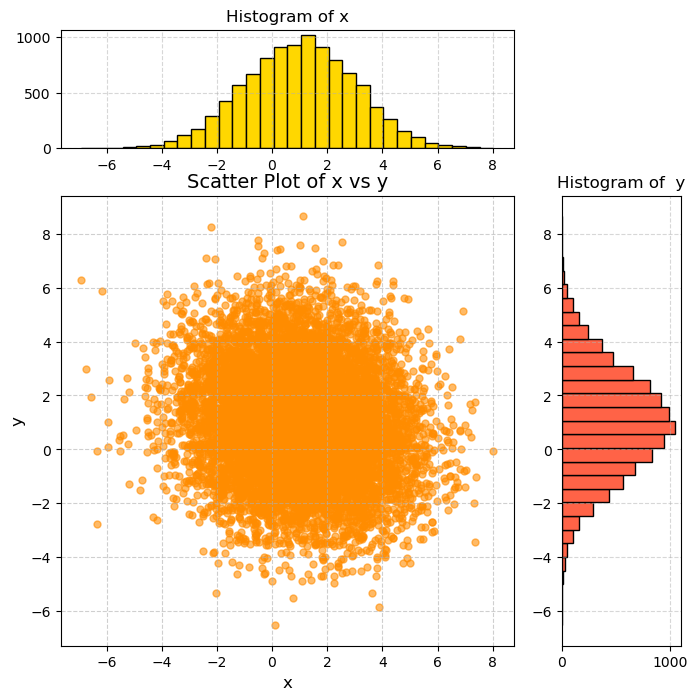

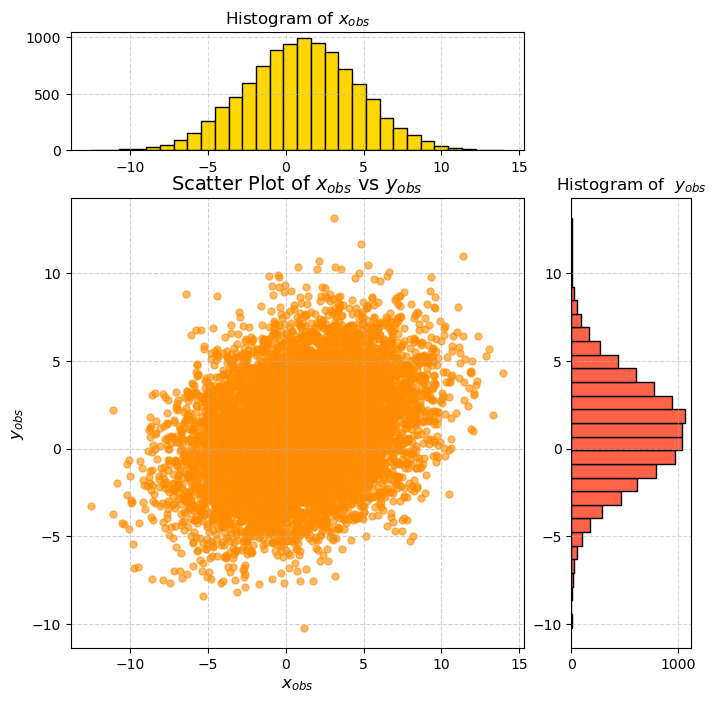

c:\Users\User\anaconda3\envs\dm1\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_x, mu_y, sigma_x, sigma_y, p]


Output()

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 111 seconds.


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_x     1.022  0.036   0.954    1.089        0.0      0.0   15136.0   
mu_y     1.032  0.028   0.977    1.083        0.0      0.0   14541.0   
sigma_x  1.952  0.047   1.865    2.040        0.0      0.0   14168.0   
sigma_y  1.991  0.028   1.937    2.044        0.0      0.0   14726.0   
p       -0.110  0.029  -0.166   -0.056        0.0      0.0   11554.0   

         ess_tail  r_hat  
mu_x      11493.0    1.0  
mu_y      11037.0    1.0  
sigma_x   12410.0    1.0  
sigma_y   10652.0    1.0  
p         11605.0    1.0  
1 0.0 -0.35










Obtaining inference for p=0.0and p2=-0.35












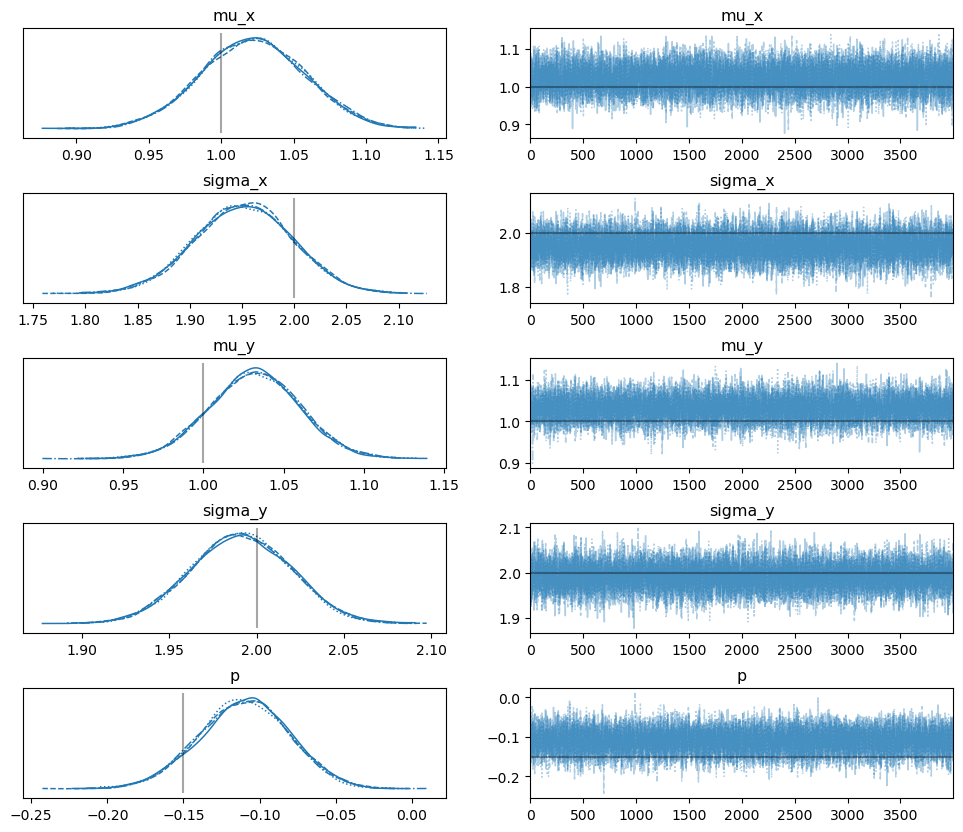

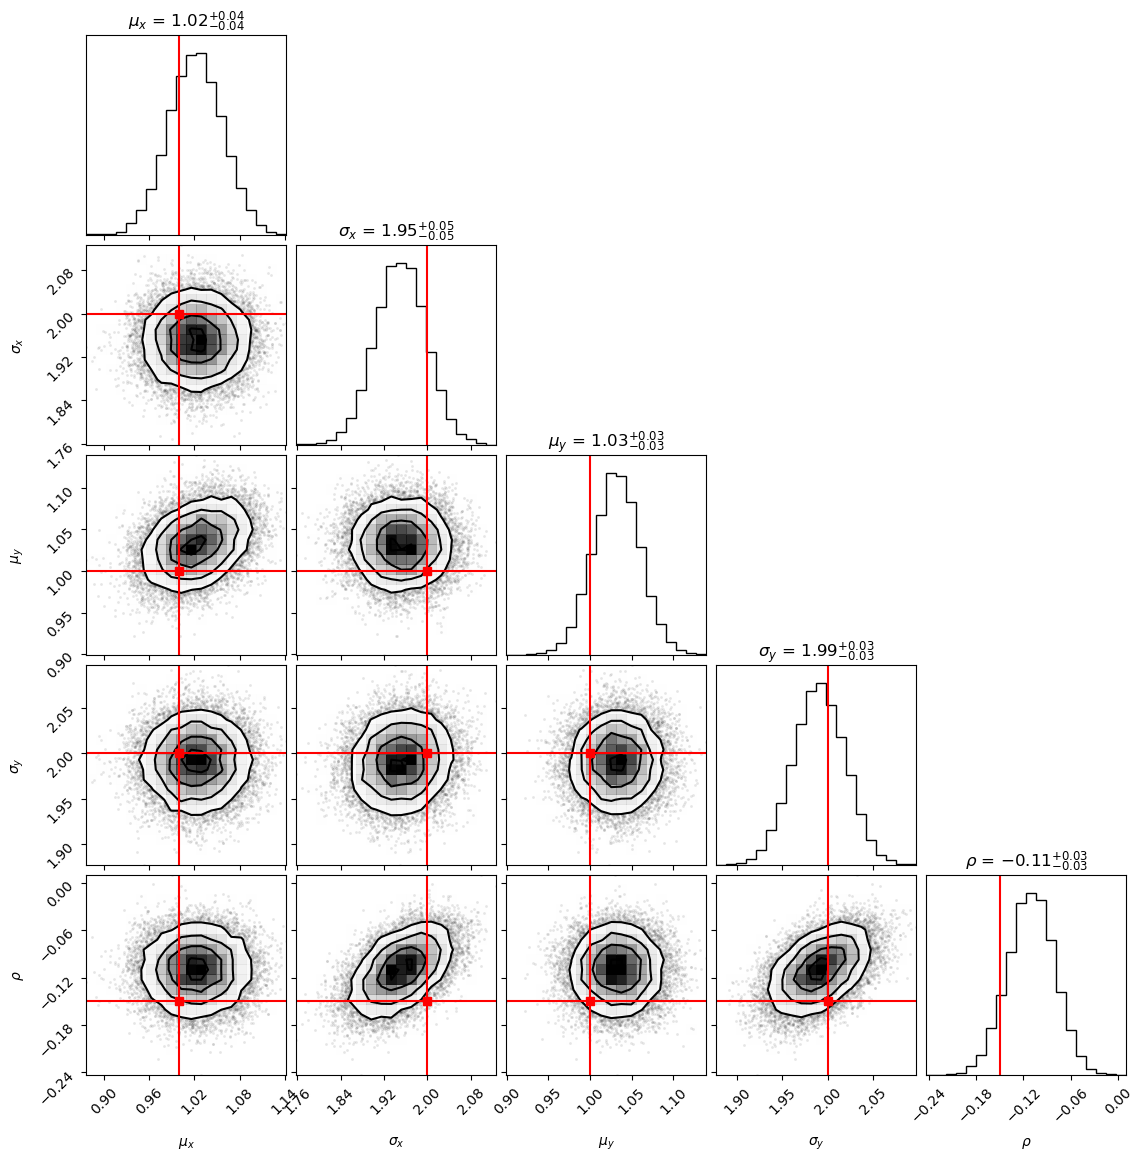

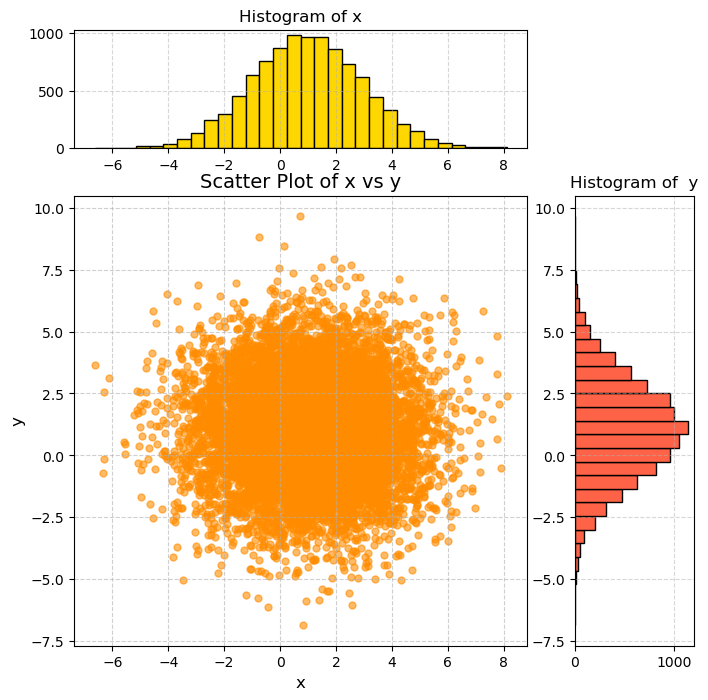

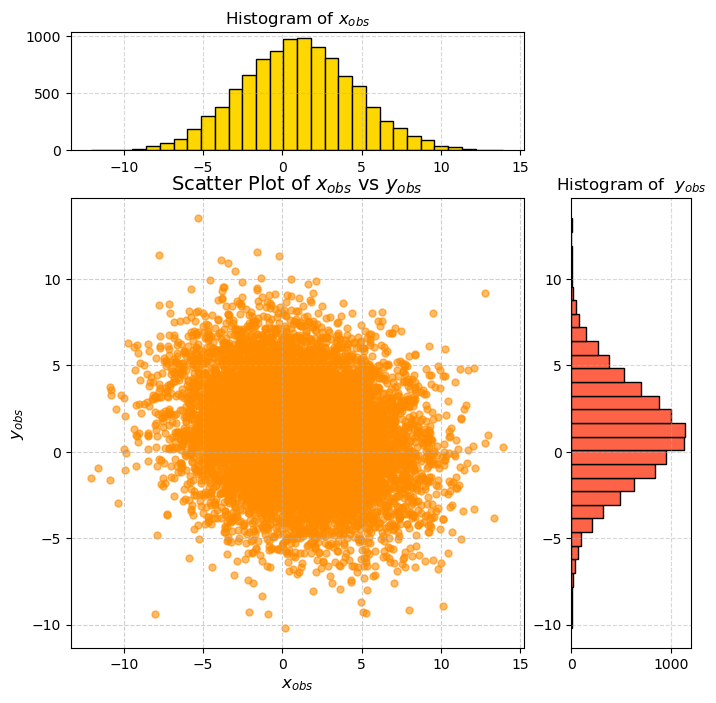

c:\Users\User\anaconda3\envs\dm1\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_x, mu_y, sigma_x, sigma_y, p]


Output()

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 94 seconds.


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_x     0.979  0.036   0.913    1.047        0.0      0.0   20455.0   
mu_y     1.029  0.028   0.975    1.082        0.0      0.0   19980.0   
sigma_x  1.934  0.046   1.847    2.021        0.0      0.0   19896.0   
sigma_y  2.042  0.028   1.989    2.095        0.0      0.0   19205.0   
p        0.002  0.027  -0.051    0.049        0.0      0.0   18613.0   

         ess_tail  r_hat  
mu_x      11384.0    1.0  
mu_y      11490.0    1.0  
sigma_x   11073.0    1.0  
sigma_y   11975.0    1.0  
p         11956.0    1.0  
2 0.0 -0.2










Obtaining inference for p=0.0and p2=-0.2












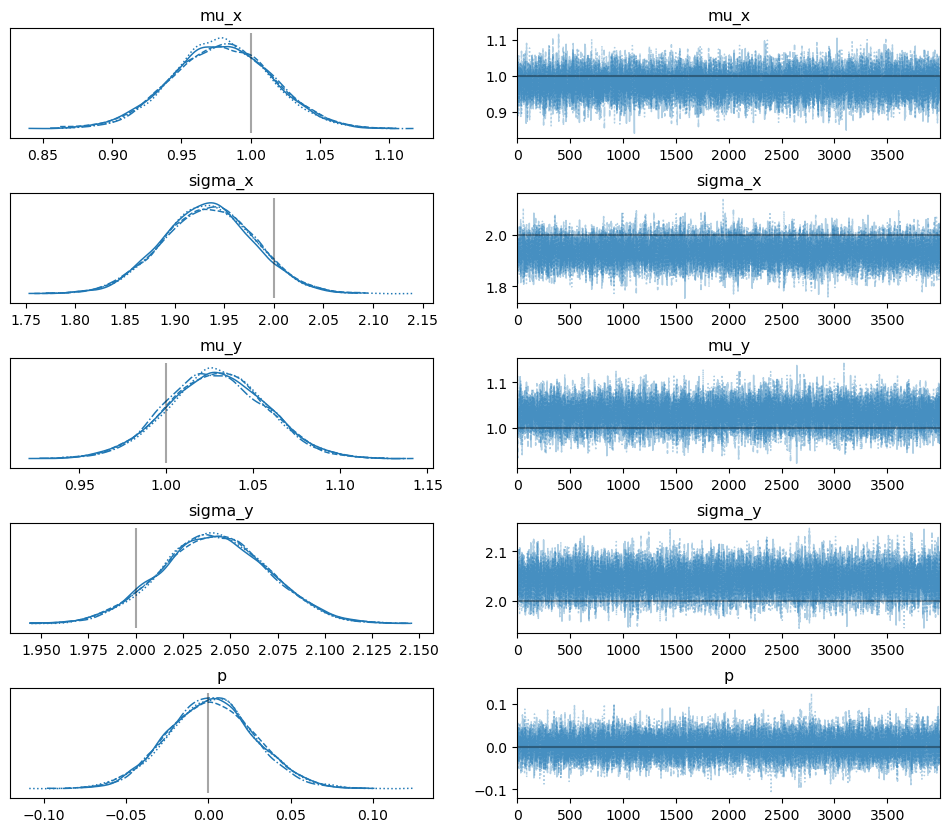

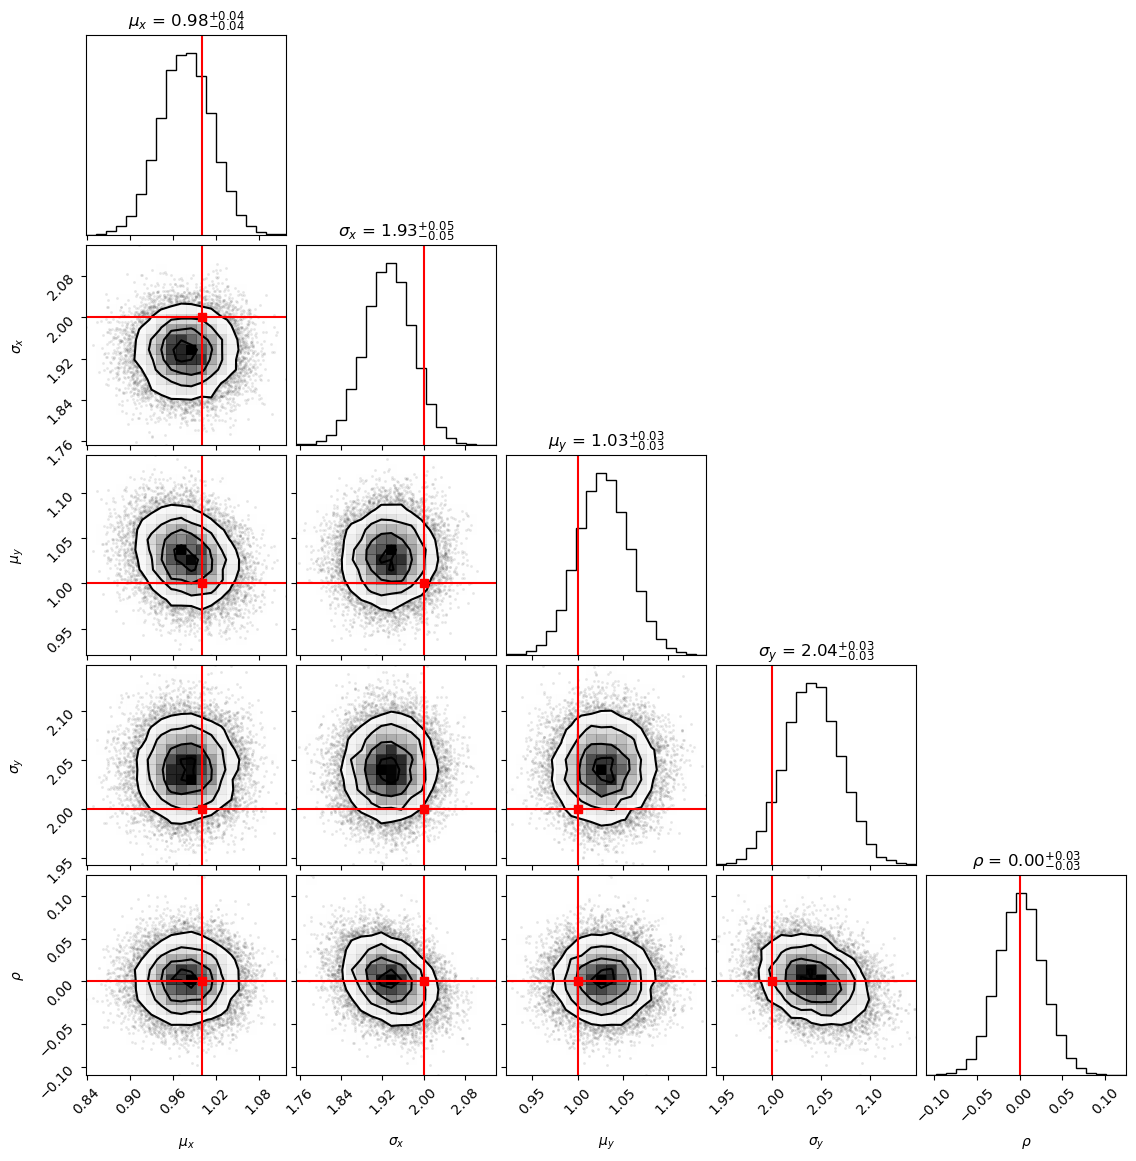

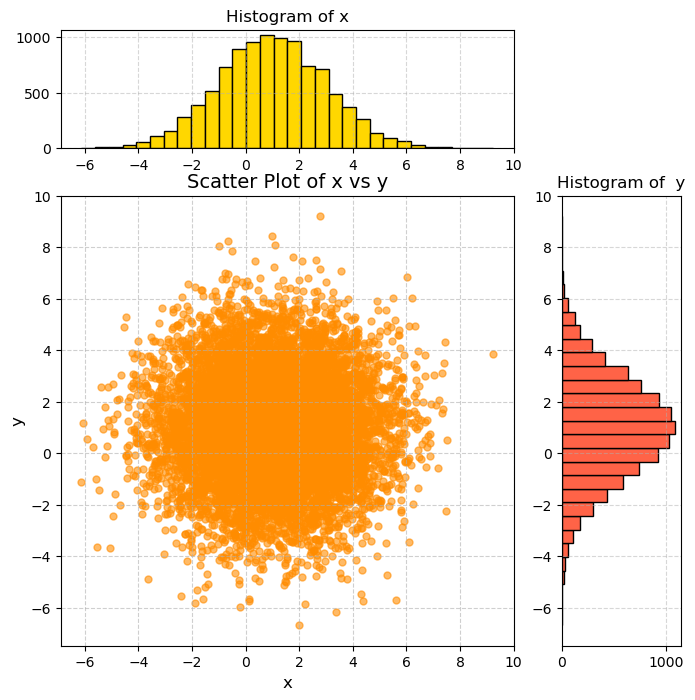

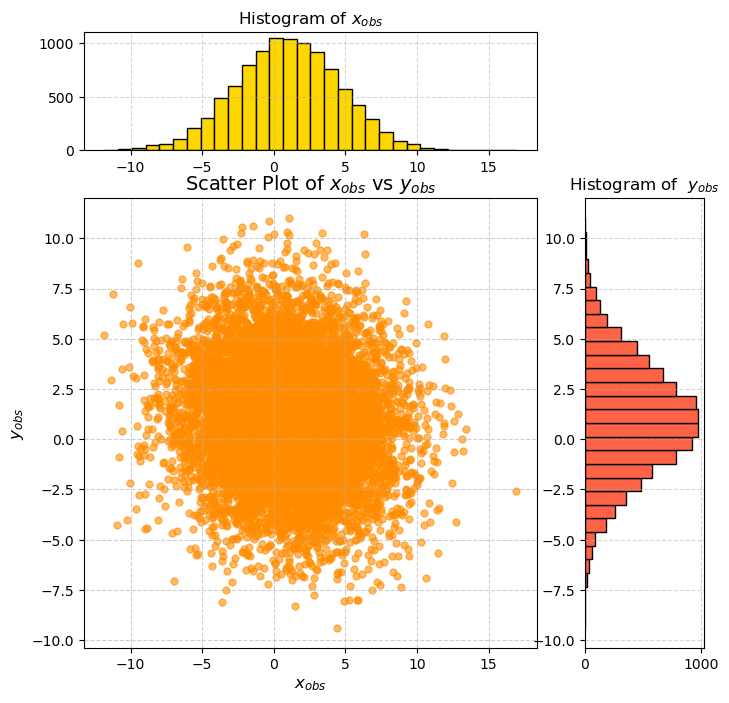

c:\Users\User\anaconda3\envs\dm1\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_x, mu_y, sigma_x, sigma_y, p]


Output()

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 91 seconds.


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_x     0.986  0.036   0.921    1.054        0.0      0.0   22656.0   
mu_y     0.993  0.028   0.941    1.046        0.0      0.0   20587.0   
sigma_x  2.020  0.046   1.934    2.105        0.0      0.0   22848.0   
sigma_y  1.987  0.028   1.932    2.038        0.0      0.0   19608.0   
p       -0.018  0.025  -0.064    0.031        0.0      0.0   21175.0   

         ess_tail  r_hat  
mu_x      10543.0    1.0  
mu_y      12069.0    1.0  
sigma_x   11759.0    1.0  
sigma_y   11577.0    1.0  
p         10845.0    1.0  


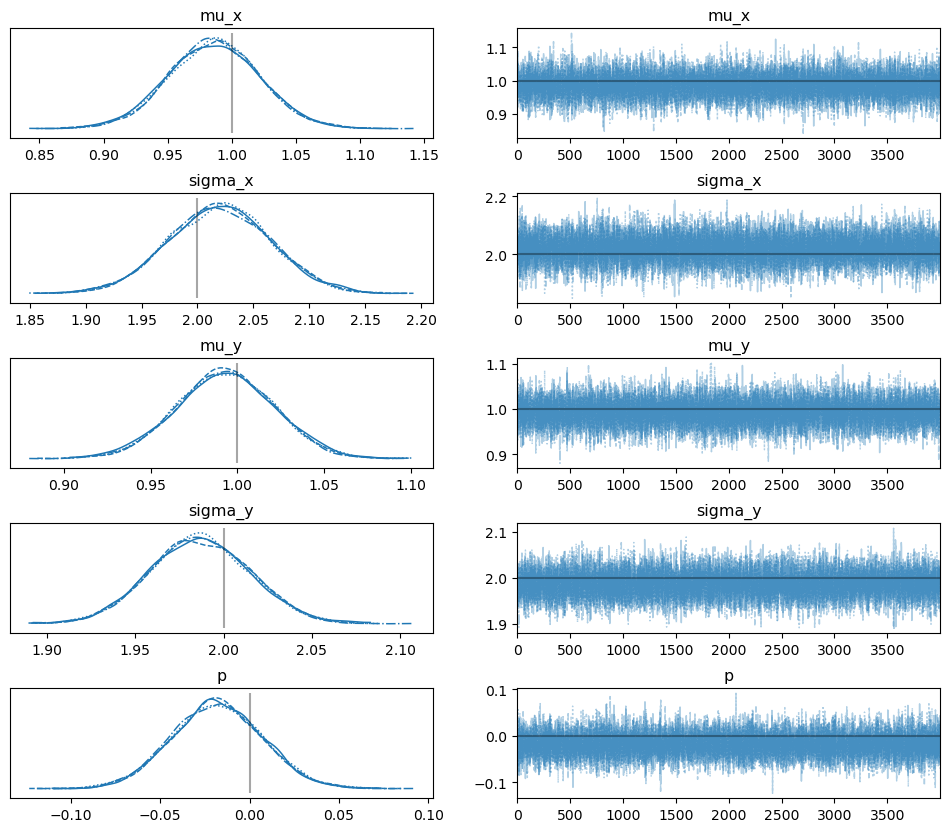

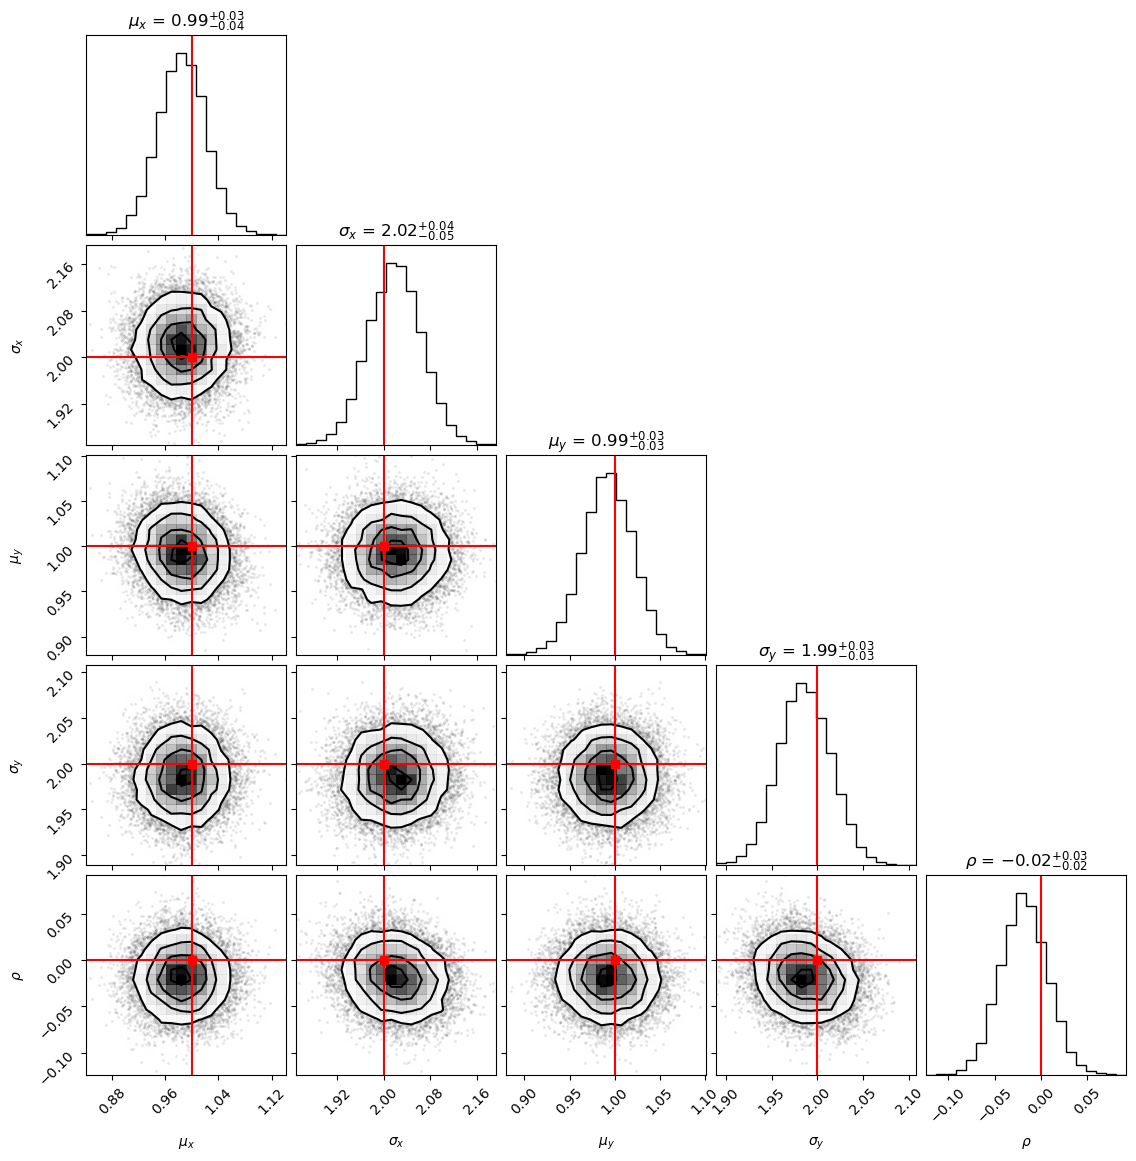

In [7]:
bias = np.loadtxt("bias.txt")

pairs = list(dict.fromkeys(zip(bias[:, 0], bias[:, 1])))

p3  = np.array([p[0] for p in pairs])
p23 = np.array([p[1] for p in pairs])

for i in range(len(p3)):
    print(i,p3[i],p23[i])
    tracemaker(p3[i],p23[i])